# Random Search Hyperparameter Tuning
**Models:** SGDClassifier vs LogisticRegression  
**Method:** RandomizedSearchCV  
**Objective:** Maximize F1 score (Toxic class)

In [ ]:
""" import sys
!{sys.executable} -m pip install -r ../requirement.txt """

' import sys\n!{sys.executable} -m pip install -r ../requirement.txt '

## Step 1: Imports

In [ ]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contractions

from scipy.sparse import hstack, csr_matrix
from scipy.stats import loguniform, randint, uniform

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, f1_score,
    roc_auc_score, ConfusionMatrixDisplay
)

print('All imports OK')

All imports OK


## Step 1.5: Constants


In [ ]:
DATA_PATH = '../data/train.csv'
LABEL_COLUMNS_TO_DROP = ['severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

SEARCH_RANDOM_STATE = 42
SEARCH_TEST_SIZE = 0.20
SEARCH_CV_SPLITS = 3
RANDOM_SEARCH_ITERATIONS = 20
SEARCH_CLASS_WEIGHTS = ['balanced', {0:1,1:3}]

WORD_TFIDF_CONFIG = {
    'ngram_range': (1, 2),
    'max_features': 10000,
    'min_df': 2,
    'max_df': 0.9,
    'sublinear_tf': True,
}
CHAR_TFIDF_CONFIG = {
    'analyzer': 'char_wb',
    'ngram_range': (3, 5),
    'max_features': 10000,
    'min_df': 2,
    'sublinear_tf': True,
}
SCALER_CONFIG = {'with_mean': False}

SGD_BASELINE_CONFIG = {
    'loss': 'modified_huber',
    'class_weight': 'balanced',
    'max_iter': 1000,
    'tol': 1e-4,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
}
LR_BASELINE_CONFIG = {
    'solver': 'liblinear',
    'penalty': 'l2',
    'C': 1.0,
    'tol': 1e-4,
    'class_weight': 'balanced',
    'max_iter': 1000,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
}

SGD_RANDOM_SEARCH_PARAM_DIST = {
    'alpha': loguniform(1e-5, 1e-3),
    'penalty': ['l2', 'l1', 'elasticnet'],
    'class_weight': SEARCH_CLASS_WEIGHTS,
    'max_iter': randint(750, 1501),
    'tol': loguniform(1e-5, 1e-3),
    'l1_ratio': uniform(0.05, 0.90),
}
LR_RANDOM_SEARCH_PARAM_DIST = {
    'C': loguniform(3e-2, 3.0),
    'class_weight': SEARCH_CLASS_WEIGHTS,
    'solver': ['liblinear', 'saga'],
    'penalty': ['l2', 'l1'],
    'tol': loguniform(1e-5, 1e-3),
}
LR_TUNED_MODEL_CONFIG = {
    'max_iter': 1000,
    'random_state': SEARCH_RANDOM_STATE,
    'n_jobs': None,
}

RANDOM_SEARCH_WORD_VECTORIZER_PATH = 'random_search_word_vectorizer.pkl'
RANDOM_SEARCH_CHAR_VECTORIZER_PATH = 'random_search_char_vectorizer.pkl'
RANDOM_SEARCH_SCALER_PATH = 'random_search_scaler.pkl'
RANDOM_SEARCH_BEST_MODEL_PATH = 'random_search_best_model.pkl'


## Step 2: Load & Clean Data

In [ ]:
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=LABEL_COLUMNS_TO_DROP)

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'[^a-z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['raw_text']   = df['comment_text'].fillna('').astype(str)
df['clean_text'] = df['raw_text'].apply(clean_text)
df = df[df['clean_text'] != ''].copy()
df = df.drop_duplicates(subset=['clean_text']).reset_index(drop=True)

print(f'Dataset shape (sampled): {df.shape}')
print(df['toxic'].value_counts())


Dataset shape (sampled): (158194, 5)
toxic
0    143038
1     15156
Name: count, dtype: int64


## Step 3: Feature Engineering

In [ ]:
PROFANITY_TERMS = [
    'fuck', 'fucking', 'shit', 'bitch', 'bastard', 'asshole', 'idiot', 'moron',
    'dumb', 'stupid', 'suck', 'crap', 'damn', 'jerk', 'loser', 'trash'
]
IDENTITY_TERMS = [
    'black', 'white', 'gay', 'lesbian', 'transgender', 'trans', 'muslim',
    'jewish', 'christian', 'hispanic', 'asian', 'woman', 'women', 'man', 'men'
]
SECOND_PERSON_TERMS = ['you', 'your', 'yours', 'yourself', 'u']
NEGATION_TERMS      = ['not', 'never', 'no', 'none', 'cannot', 'cant', 'do not']
NON_TOXIC_NEGATION_PATTERNS = [
    r'\bnot\s+(?:stupid|dumb|idiot|moron|trash|wrong|bad|terrible|awful|useless)\b',
    r'\bnot\s+(?:an|a)\s+(?:idiot|moron|loser|bastard|fool)\b',
    r'\bdo\s+not\s+(?:like|love|agree|hate|dislike|attack|insult|blame)\b',
    r'\bcannot\s+(?:hate|blame)\b',
    r'\bnot\s+trying\s+to\s+(?:attack|insult|offend)\b',
]
COMMON_SHORT_TOKENS = {
    'i','me','my','you','your','yours','yourself','it','this','that',
    'a','an','the','is','am','are','was','were','be','to','of','and'
}

def make_term_pattern(terms):
    escaped = sorted((re.escape(t) for t in terms), key=len, reverse=True)
    return re.compile(r'\b(?:' + '|'.join(escaped) + r')\b')

PROFANITY_PATTERN          = make_term_pattern(PROFANITY_TERMS)
IDENTITY_PATTERN           = make_term_pattern(IDENTITY_TERMS)
SECOND_PERSON_PATTERN      = make_term_pattern(SECOND_PERSON_TERMS)
NEGATION_PATTERN           = make_term_pattern(NEGATION_TERMS)
NON_TOXIC_NEGATION_PATTERN = re.compile('|'.join(NON_TOXIC_NEGATION_PATTERNS))

def count_pattern(text, pattern):
    return len(pattern.findall(str(text).lower()))
def repeated_characters_score(text):
    return len(re.findall(r'(.)\1{2,}', str(text).lower()))
def repeated_punctuation_count(text):
    return len(re.findall(r'([!?.,])\1+', str(text)))
def uppercase_ratio(text):
    letters = re.findall(r'[A-Za-z]', str(text))
    return sum(1 for c in letters if c.isupper()) / len(letters) if letters else 0.0
def short_unclear_without_toxic_signal(clean_text, profanity_count):
    tokens = str(clean_text).split()
    content_tokens = [t for t in tokens if t not in COMMON_SHORT_TOKENS]
    return int((len(tokens) < 3 or len(content_tokens) < 1) and profanity_count == 0)

df['Character Count']                   = df['raw_text'].apply(len)
df['Word Count']                        = df['clean_text'].apply(lambda x: len(x.split()))
df['Exclamation Count']                 = df['raw_text'].str.count('!')
df['Profanity Count']                   = df['clean_text'].apply(lambda x: count_pattern(x, PROFANITY_PATTERN))
df['Strong Toxic Signal Flag']          = (df['Profanity Count'] > 0).astype(int)
df['Second-person Pronoun Count']       = df['clean_text'].apply(lambda x: count_pattern(x, SECOND_PERSON_PATTERN))
df['Repeated Character Pattern Count'] = df['raw_text'].apply(repeated_characters_score)
df['Average Word Length']               = df['clean_text'].apply(
    lambda x: sum(len(w) for w in x.split()) / len(x.split()) if x.split() else 0)
df['Uppercase Ratio']                         = df['raw_text'].apply(uppercase_ratio)
df['Question Mark Count']                     = df['raw_text'].str.count(r'\?')
df['Repeated Punctuation Count']              = df['raw_text'].apply(repeated_punctuation_count)
df['Identity-group Term Count']               = df['clean_text'].apply(lambda x: count_pattern(x, IDENTITY_PATTERN))
df['URL Count']                               = df['raw_text'].str.count(r'http\S+|www\S+')
df['Negation Count']                          = df['clean_text'].apply(lambda x: count_pattern(x, NEGATION_PATTERN))
df['Non-toxic Negation Pattern Count']        = df['clean_text'].apply(lambda x: count_pattern(x, NON_TOXIC_NEGATION_PATTERN))
df['Short/Unclear Without Toxic Signal Flag'] = df.apply(
    lambda row: short_unclear_without_toxic_signal(row['clean_text'], row['Profanity Count']), axis=1)

print('Feature engineering done')

KeyboardInterrupt: 

## Step 4: Train/Test Split & Vectorize

In [ ]:
ENG_FEATURE_COLS = [
    'Character Count', 'Word Count', 'Exclamation Count',
    'Profanity Count', 'Strong Toxic Signal Flag',
    'Second-person Pronoun Count', 'Repeated Character Pattern Count',
    'Average Word Length',
    'Uppercase Ratio', 'Question Mark Count', 'Repeated Punctuation Count',
    'Identity-group Term Count', 'URL Count', 'Negation Count',
    'Non-toxic Negation Pattern Count', 'Short/Unclear Without Toxic Signal Flag'
]

X_raw   = df['raw_text']
X_clean = df['clean_text']
X_eng   = df[ENG_FEATURE_COLS]
y       = df['toxic']

(
    X_raw_train,   X_raw_test,
    X_clean_train, X_clean_test,
    X_eng_train,   X_eng_test,
    y_train,       y_test
) = train_test_split(
    X_raw, X_clean, X_eng, y,
    test_size=SEARCH_TEST_SIZE,
    random_state=SEARCH_RANDOM_STATE,
    stratify=y,
)

word_vec = TfidfVectorizer(**WORD_TFIDF_CONFIG)
char_vec = TfidfVectorizer(**CHAR_TFIDF_CONFIG)
scaler = StandardScaler(**SCALER_CONFIG)

X_word_train = word_vec.fit_transform(X_clean_train)
X_word_test  = word_vec.transform(X_clean_test)
X_char_train = char_vec.fit_transform(X_raw_train)
X_char_test  = char_vec.transform(X_raw_test)
X_eng_train_scaled = scaler.fit_transform(X_eng_train.values)
X_eng_test_scaled  = scaler.transform(X_eng_test.values)

X_train = hstack([X_word_train, X_char_train, csr_matrix(X_eng_train_scaled)], format='csr')
X_test  = hstack([X_word_test,  X_char_test,  csr_matrix(X_eng_test_scaled)], format='csr')

print(f'Train: {len(y_train):,}  |  Test: {len(y_test):,}')
print(f'Feature matrix (train): {X_train.shape}')
print(f'Feature matrix (test) : {X_test.shape}')


## Step 5: Baseline (ก่อน Tuning)
> เทรน SGD และ LR ด้วย default params เพื่อใช้เปรียบเทียบ

In [ ]:
# Baseline SGD
sgd_base = SGDClassifier(**SGD_BASELINE_CONFIG)
sgd_base.fit(X_train, y_train)
f1_sgd_base = f1_score(y_test, sgd_base.predict(X_test))

# Baseline LR
lr_base = LogisticRegression(**LR_BASELINE_CONFIG)
lr_base.fit(X_train, y_train)
f1_lr_base = f1_score(y_test, lr_base.predict(X_test))

print(f'Baseline SGD F1 : {f1_sgd_base:.4f}')
print(f'Baseline LR  F1 : {f1_lr_base:.4f}')


## Step 6: Random Search — SGDClassifier

Shared environment with the other tuning notebooks:
- 3-fold stratified CV
- 20 search candidates per model
- 10k word TF-IDF + 10k char TF-IDF + engineered features
- same class-weight candidate list
- target runtime: roughly development-scale, not quick smoke-test


In [ ]:
cv = StratifiedKFold(
    n_splits=SEARCH_CV_SPLITS,
    shuffle=True,
    random_state=SEARCH_RANDOM_STATE,
)

sgd_rs = RandomizedSearchCV(
    SGDClassifier(loss='modified_huber', random_state=SEARCH_RANDOM_STATE, n_jobs=None),
    param_distributions=SGD_RANDOM_SEARCH_PARAM_DIST,
    n_iter=RANDOM_SEARCH_ITERATIONS,
    scoring='f1',
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1,
    random_state=SEARCH_RANDOM_STATE,
)

print(f'SGD Random Search ({RANDOM_SEARCH_ITERATIONS} iter x {SEARCH_CV_SPLITS}-fold)...')
sgd_rs.fit(X_train, y_train)

print(f'\nBest CV F1  : {sgd_rs.best_score_:.4f}')
print(f'Best Params : {sgd_rs.best_params_}')


## Step 7: Random Search — LogisticRegression

The LR search compares `solver in ['liblinear', 'saga']` and `penalty in ['l1', 'l2']` with `max_iter=1000`, matching the other tuning notebooks.


In [ ]:
lr_rs = RandomizedSearchCV(
    LogisticRegression(**LR_TUNED_MODEL_CONFIG),
    param_distributions=LR_RANDOM_SEARCH_PARAM_DIST,
    n_iter=RANDOM_SEARCH_ITERATIONS,
    scoring='f1',
    cv=cv,
    refit=True,
    verbose=1,
    random_state=SEARCH_RANDOM_STATE,
    n_jobs=-1,
)

print(f'LR Random Search ({RANDOM_SEARCH_ITERATIONS} iter x {SEARCH_CV_SPLITS}-fold)...')
lr_rs.fit(X_train, y_train)

print(f'\nBest CV F1  : {lr_rs.best_score_:.4f}')
print(f'Best Params : {lr_rs.best_params_}')


## Step 8: Evaluate & Compare ทั้งหมด

In [ ]:
models = {
    'Baseline SGD': sgd_base,
    'Baseline LR':  lr_base,
    'Tuned SGD':    sgd_rs.best_estimator_,
    'Tuned LR':     lr_rs.best_estimator_,
}

print(f"{'Model':<15} {'F1':>8} {'ROC-AUC':>10}")
print('-' * 36)

scores = {}
for name, m in models.items():
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:, 1]
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    scores[name] = {'f1': f1, 'auc': auc, 'pred': y_pred}
    print(f'{name:<15} {f1:>8.4f} {auc:>10.4f}')

Model                 F1    ROC-AUC
------------------------------------
Baseline SGD      0.5967     0.9462
Baseline LR       0.7137     0.9698
Tuned SGD         0.7354     0.9595
Tuned LR          0.7706     0.9649


In [ ]:
# Classification Report ของ tuned models
for name in ['Tuned SGD', 'Tuned LR']:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, scores[name]['pred'], target_names=['Not Toxic', 'Toxic']))


=== Tuned SGD ===
              precision    recall  f1-score   support

   Not Toxic       0.97      0.97      0.97     28608
       Toxic       0.74      0.73      0.74      3031

    accuracy                           0.95     31639
   macro avg       0.86      0.85      0.85     31639
weighted avg       0.95      0.95      0.95     31639


=== Tuned LR ===
              precision    recall  f1-score   support

   Not Toxic       0.97      0.98      0.98     28608
       Toxic       0.82      0.72      0.77      3031

    accuracy                           0.96     31639
   macro avg       0.90      0.85      0.87     31639
weighted avg       0.96      0.96      0.96     31639



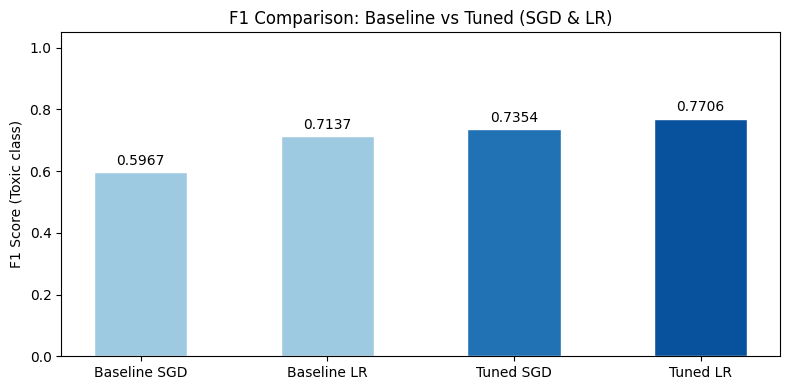

In [ ]:
# Bar chart เปรียบเทียบ F1
names  = list(scores.keys())
f1s    = [scores[n]['f1'] for n in names]
colors = ['#9ecae1', '#9ecae1', '#2171b5', '#08519c']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, f1s, color=colors, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='{:.4f}', padding=3, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score (Toxic class)')
ax.set_title('F1 Comparison: Baseline vs Tuned (SGD & LR)')
plt.tight_layout()
plt.show()

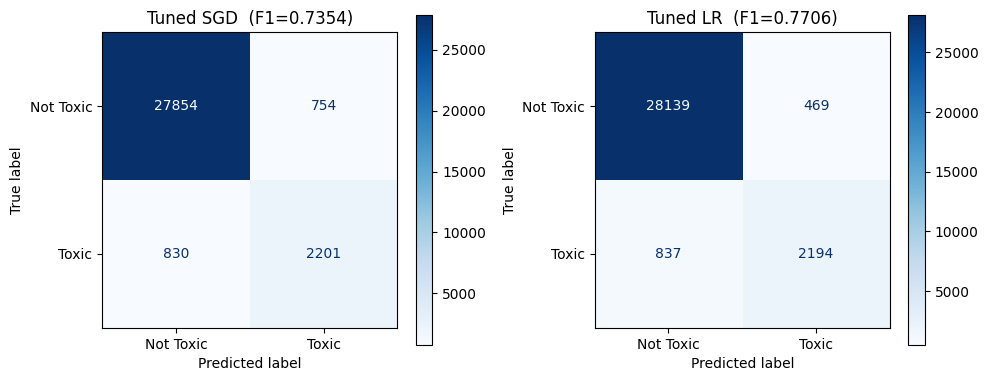

In [ ]:
# Confusion Matrix ของ tuned models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ['Tuned SGD', 'Tuned LR']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, scores[name]['pred'],
        display_labels=['Not Toxic', 'Toxic'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'{name}  (F1={scores[name]["f1"]:.4f})')
plt.tight_layout()
plt.show()

## Step 9: Save Best Model Overall

In [ ]:
# Choose the best tuned model and save method-specific artifacts.
best_name  = max(['Tuned SGD', 'Tuned LR'], key=lambda n: scores[n]['f1'])
best_model = models[best_name]

print(f'Best overall model : {best_name}')
print(f'Test F1            : {scores[best_name]["f1"]:.4f}')

with open(RANDOM_SEARCH_WORD_VECTORIZER_PATH, 'wb') as f:
    pickle.dump(word_vec, f)
with open(RANDOM_SEARCH_CHAR_VECTORIZER_PATH, 'wb') as f:
    pickle.dump(char_vec, f)
with open(RANDOM_SEARCH_SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)
with open(RANDOM_SEARCH_BEST_MODEL_PATH, 'wb') as f:
    pickle.dump(best_model, f)

print(f'Saved: {RANDOM_SEARCH_BEST_MODEL_PATH}')
print(f'Saved: {RANDOM_SEARCH_WORD_VECTORIZER_PATH} / {RANDOM_SEARCH_CHAR_VECTORIZER_PATH} / {RANDOM_SEARCH_SCALER_PATH}')


In [ ]:
# Step 10: ทดสอบคำ / ประโยค
def predict_toxic(text, model, word_vec, char_vec, scaler):
    # Clean
    raw = str(text)
    clean = clean_text(raw)

    # TF-IDF
    X_word = word_vec.transform([clean])
    X_char = char_vec.transform([raw])

    # Engineering features
    prof_count = count_pattern(clean, PROFANITY_PATTERN)
    eng = [[
        len(raw), len(clean.split()), raw.count('!'),
        prof_count, int(prof_count > 0),
        count_pattern(clean, SECOND_PERSON_PATTERN),
        repeated_characters_score(raw),
        sum(len(w) for w in clean.split()) / len(clean.split()) if clean.split() else 0,
        uppercase_ratio(raw), raw.count('?'),
        repeated_punctuation_count(raw),
        count_pattern(clean, IDENTITY_PATTERN),
        len(re.findall(r'http\S+|www\S+', raw)),
        count_pattern(clean, NEGATION_PATTERN),
        count_pattern(clean, NON_TOXIC_NEGATION_PATTERN),
        short_unclear_without_toxic_signal(clean, prof_count)
    ]]
    X_eng = scaler.transform(eng)
    X = hstack([X_word, X_char, csr_matrix(X_eng)])

    pred = model.predict(X)[0]
    prob = model.predict_proba(X)[0][1]
    label = '🔴 TOXIC' if pred == 1 else '🟢 NOT TOXIC'
    print(f'{label}  (confidence: {prob:.2%})')

# ── ใส่ประโยคที่ต้องการทดสอบได้เลย ──
predict_toxic("you are so stupid", best_model, word_vec, char_vec, scaler)
predict_toxic("you are not stupid", best_model, word_vec, char_vec, scaler)
predict_toxic("thank you for your help", best_model, word_vec, char_vec, scaler)
predict_toxic("I disagree with your opinion", best_model, word_vec, char_vec, scaler)

🔴 TOXIC  (confidence: 99.29%)
🔴 TOXIC  (confidence: 99.61%)
🟢 NOT TOXIC  (confidence: 0.67%)
🟢 NOT TOXIC  (confidence: 6.69%)
